### 🧠 What is a WGAN?

A Wasserstein GAN is a special kind of GAN (Generative Adversarial Network) designed to make training more stable and produce better quality outputs (like images).

🧩 Real-World Analogy

Imagine:

-	A forger (generator) is trying to create fake paintings that look real.
-	An art critic (discriminator) is trying to judge how real or fake each painting is.

In classic GANs, the critic says “real” or “fake” — like a binary answer. But this often leads to fights and instability.

In WGAN, the critic doesn’t say yes/no. Instead, they give a score — like:

“This painting looks 70% real.”

This smooth scoring system helps the forger improve gradually, rather than guessing randomly.

✅ Why WGAN is Better:
-	More stable training (less likely to crash).
-	Avoids mode collapse (where generator produces only one kind of output).
-	Gives useful loss values (loss actually means something, unlike in normal GANs).

# Wasserstein GAN (WGAN) using the MNIST dataset

- **Imports**

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,LeakyReLU,Conv2DTranspose,Reshape,Flatten,BatchNormalization
from tensorflow.keras.optimizers import RMSprop

- **Load MNIST AND VISUALIZE**

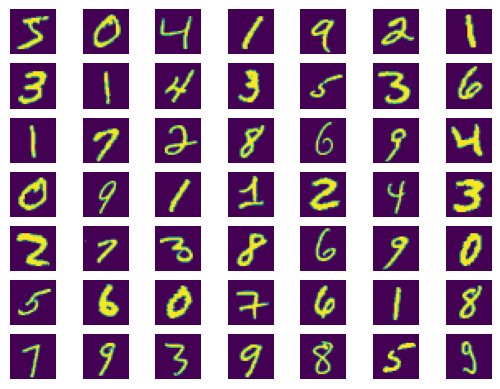

In [2]:
(train_image,_),(_,_) = mnist.load_data()

for i in range(49):
  plt.subplot(7,7,i+1)
  plt.axis('off')
  plt.imshow(train_image[i])
plt.show()

In [4]:
train_image = train_image.astype('float32')
train_image = (train_image - 127.5) / 127.5
train_image = np.expand_dims(train_image,axis=-1)
print(train_image.shape)

(60000, 28, 28, 1)


- **Create TensorFlow dataset**

In [5]:
batch_size = 64
dataset = tf.data.Dataset.from_tensor_slices(train_image)
dataset = dataset.shuffle(60000)
dataset = dataset.batch(batch_size,drop_remainder=True)

- **GENERATOR**

In [7]:
def build_generator(noise_dim=100):
  model = Sequential([

      # 100 → 7×7×256
      Dense(7*7*256,input_shape=(noise_dim,)),
      BatchNormalization(),
      LeakyReLU(0.2),
      Reshape((7,7,256)),

      # 7×7 → 14×14
      Conv2DTranspose(128,kernel_size=4,strides=2,padding='same'),
      BatchNormalization(),
      LeakyReLU(0.2),

      # 14×14 → 28×28
      Conv2DTranspose(64,kernel_size=4,strides=2,padding='same'),
      BatchNormalization(),
      LeakyReLU(0.2),

      # 28×28×32 → 28×28×1
      Conv2D(1,kernel_size=7,padding='same',activation='tanh')
  ])
  return model



generator = build_generator()
generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,266,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,976,577 (7.54 MB)

 Trainable params: 1,951,105 (7.44 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [ ]:
def build_critic():
  model = Sequenti